In [18]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('../data/raw/bengaluru_house_prices.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## Data Cleaning

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


so there is a 9 columns in dataset from these 6 columns is 'string' datatype and 3 is 'float' data type columns and there is some null values in 'location,size,society,bath,balcony' columns so i need to Handle these all things     

In [21]:
# check the null values in dataset
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

As above I can see there is 1 in location, 16 in size, 5502 in society, 73 in bath, 609 in balcony missing values.

In [22]:
# check how much present of the dataset is missing in every columns 
df.isnull().mean()*100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

As above I can see there is 0.0045% in location, 0.12% in size, 41.3% in society, 0.54% in bath, 4.57% in balcony missing values.

In [23]:
# as above information our society columns have 41.3% of missing values let's drop 
df = df.drop("society", axis=1)


The column had 41% missing values and very high cardinality. Since location already captured geographical information, keeping society could introduce sparsity and overfitting. Therefore I removed it during preprocessing.

In [24]:
# let's drop the romve location missing value (it's only one)
df.dropna(subset=["location"], inplace=True)


There is only one missing value so it will not effect on my data if i am removing

In [25]:
df['location'].isnull().sum()

np.int64(0)

In [26]:
df['size'].unique()

<StringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',      '4 BHK',  '6 Bedroom',
  '3 Bedroom',      '1 BHK',       '1 RK',  '1 Bedroom',  '8 Bedroom',
  '2 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',          nan,  '9 Bedroom',
     '27 BHK', '10 Bedroom', '11 Bedroom',     '10 BHK',     '19 BHK',
     '16 BHK', '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',
     '13 BHK', '18 Bedroom']
Length: 32, dtype: str

Ok so as above we can see we have "BHK","Bedroom", "RK" types of category, but not in way which can be use in ML model so let's do some string operations on this column.

In [27]:
# create column as "room_count" from "size"
#example - 2BHK - 2
        #  3RK -  3
        #  1 bedroom - 1
df['room_count'] = df['size'].str.split().str[0]

In [28]:
# create column as "property_type" from "size"
#example - 2BHK - BHK
        #  3RK -  RK
        #  1 bedroom - bedroom
df['property_type'] = df['size'].str.split().str[1]

In [29]:
df.drop(columns=['size'], inplace=True)

In [36]:
df.isnull().sum()

area_type          0
availability       0
location           0
total_sqft         0
bath              73
balcony          609
price              0
room_count        16
property_type     16
dtype: int64

In [52]:
df["balcony"] = df["balcony"].fillna(df["balcony"].median())

I used median imputation for the balcony feature because the missing percentage was low and median is more robust to outliers than mean.

In [70]:
bath_median = df['bath'].median()
df["bath"] = df["bath"].fillna(bath_median)

I used median imputation for the bath feature.Here also missing percentage was low and median is more robust to use

<Axes: xlabel='property_type', ylabel='count'>

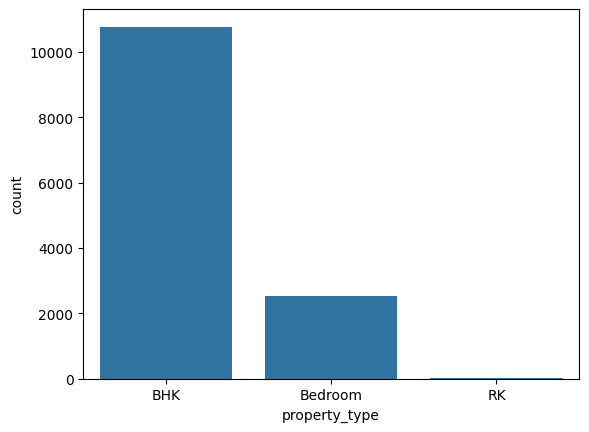

In [94]:
sns.countplot(data=df,x='property_type')

Because the missing percentage was very small and BHK was the dominant category, mode imputation was a reasonable and statistically stable choice.

In [102]:
mode_property_type = df['property_type'].mode()[0]
df['property_type'] = df['property_type'].fillna(mode_property_type)

In [ ]:
# convert type object -> int
df['room_count'] = df['room_count'].astype('Int64')

In [123]:
room_count_median = df['room_count'].median()
df['room_count'] = df['room_count'].fillna(room_count_median)

In [125]:
df.isnull().sum()

area_type        0
availability     0
location         0
total_sqft       0
bath             0
balcony          0
price            0
room_count       0
property_type    0
dtype: int64